# Load Data

In [3]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target

In [4]:
import numpy as np

def make_hiv_like_subset(X, y, n0=23, n1=68, seed=42):
    rng = np.random.default_rng(seed)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    if len(idx0) < n0 or len(idx1) < n1:
        raise ValueError(
            f"Not enough samples: class 0 has {len(idx0)}, class 1 has {len(idx1)}"
        )

    take0 = rng.choice(idx0, size=n0, replace=False)
    take1 = rng.choice(idx1, size=n1, replace=False)

    keep_idx = np.concatenate([take0, take1])
    rng.shuffle(keep_idx)

    return X[keep_idx], y[keep_idx], keep_idx

# make HIV-sized breast cancer subset
X, y, idx_small = make_hiv_like_subset(X, y, n0=23, n1=68, seed=42)

print("Subset shape:", X.shape)
print("Class 0 count:", (y == 0).sum())
print("Class 1 count:", (y).sum())

Subset shape: (91, 30)
Class 0 count: 23
Class 1 count: 68


In [5]:
print(X.shape)  # should be (569, 30)
print(y.shape)
print("Classes:", set(y))

(91, 30)
(91,)
Classes: {np.int64(0), np.int64(1)}


## Standardize

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

## Conver to tensors

In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)

# CVAE

In [8]:
# models/cvae.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class CVAE(nn.Module):
    """
    Conditional VAE for tabular features.

    Encoder: [x, c] -> (mu, logvar)
    Reparam: z = mu + exp(0.5*logvar) * eps
    Decoder: [z, c] -> x_hat
    """
    def __init__(self, x_dim: int, c_dim: int, z_dim: int, hidden: int):
        super().__init__()
        self.x_dim = x_dim
        self.c_dim = c_dim
        self.z_dim = z_dim

        # Encoder
        self.enc = nn.Sequential(
            nn.Linear(x_dim + c_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden, z_dim)
        self.logvar = nn.Linear(hidden, z_dim)

        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(z_dim + c_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, x_dim),  # linear output for MSE/Gaussian recon
        )

    def encode(self, x: torch.Tensor, c: torch.Tensor):
        xc = torch.cat([x, c], dim=1)
        h = self.enc(xc)
        return self.mu(h), self.logvar(h)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor):
        eps = torch.randn_like(mu)
        sigma = torch.exp(0.5 * logvar)
        return mu + sigma * eps

    def decode(self, z: torch.Tensor, c: torch.Tensor):
        zc = torch.cat([z, c], dim=1)
        return self.dec(zc)

    def forward(self, x: torch.Tensor, c: torch.Tensor):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, c)
        return x_hat, mu, logvar
    
if __name__ == "__main__":
    # Quick test
    x_dim, c_dim, z_dim, hidden = 10, 2, 4, 16
    model = CVAE(x_dim, c_dim, z_dim, hidden)
    x = torch.randn(5, x_dim)
    c = F.one_hot(torch.randint(0, c_dim, (5,)), num_classes=c_dim).float()
    x_hat, mu, logvar = model(x, c)
    print("x_hat shape:", x_hat.shape)
    print("mu shape:", mu.shape)
    print("logvar shape:", logvar.shape)

x_hat shape: torch.Size([5, 10])
mu shape: torch.Size([5, 4])
logvar shape: torch.Size([5, 4])


In [9]:
def elbo_loss(x, x_hat, mu, logvar, beta=1.0):
    recon = ((x - x_hat)**2).sum(dim=1).mean()
    kl = (-0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(dim=1)).mean()
    return recon + beta * kl

In [10]:
from dataclasses import dataclass

@dataclass
class Config:
    seed: int = 42

    # CVAE hyperparameters
    z_dim: int = 16
    hidden: int = 128
    beta: float = 0.5
    epochs: int = 200
    batch_size: int = 64
    lr: float = 1e-3

# Now the stuff that can actually chage

In [11]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1) config
cfg = Config()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

# 2) split + scale (NO log1p for now, keep it simple)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size= 0.2, random_state=cfg.seed, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

# 3) loaders
device = "cuda" if torch.cuda.is_available() else "cpu"

X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=cfg.batch_size,
    shuffle=True
)

# 4) train CVAE
model = CVAE(x_dim=X_tr_s.shape[1], c_dim=2, z_dim=cfg.z_dim, hidden=cfg.hidden).to(device)
opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

for epoch in range(cfg.epochs):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        cb = F.one_hot(yb, num_classes=2).float()

        x_hat, mu, logvar = model(xb, cb)
        loss = elbo_loss(xb, x_hat, mu, logvar, beta=cfg.beta)

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * xb.size(0)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | loss={total/len(X_tr_t):.4f}")

# 5) sample synthetic in SCALED space
@torch.no_grad()
def sample_scaled(model, n, y_label, device):
    model.eval()
    z = torch.randn(n, model.z_dim, device=device)
    c = F.one_hot(torch.full((n,), y_label, dtype=torch.long, device=device), num_classes=2).float()
    x_scaled = model.decode(z, c)
    return x_scaled.cpu().numpy()

n0 = int((y_te == 0).sum())
n1 = int((y_te == 1).sum())

X_syn0 = sample_scaled(model, n0, y_label=0, device=device)
X_syn1 = sample_scaled(model, n1, y_label=1, device=device)
X_syn  = np.vstack([X_syn0, X_syn1])
y_syn = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
# 6) distinguishability AUC (proper split)
def distinguishability_auc_proper(X_real, X_syn, seed=0):
    X_all = np.vstack([X_real, X_syn])
    s_all = np.concatenate([np.zeros(len(X_real), dtype=int),
                            np.ones(len(X_syn), dtype=int)])

    Xtr, Xte, str_, ste = train_test_split(
        X_all, s_all, test_size=0.2, random_state=seed, stratify=s_all
    )

    rf = RandomForestClassifier(n_estimators=500, random_state=seed)
    rf.fit(Xtr, str_)
    p = rf.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(ste, p)
    return auc

auc = distinguishability_auc_proper(X_te_s, X_syn, seed=0)
sep = max(auc, 1-auc)

print("Distinguishability AUC:", auc)
print("Separability:", sep)
print("Target: separability close to 0.5")

Epoch  50 | loss=13.5607
Epoch 100 | loss=10.9180
Epoch 150 | loss=9.4688
Epoch 200 | loss=8.5523
Distinguishability AUC: 0.71875
Separability: 0.71875
Target: separability close to 0.5


RF AUC: 0.71875 RF separability: 0.71875
Flattened AUC: 0.49082794706063404 Flattened separability: 0.509172052939366
Top 5 feature separabilities: [0.70083102 0.67313019 0.6565097  0.65096953 0.65096953]


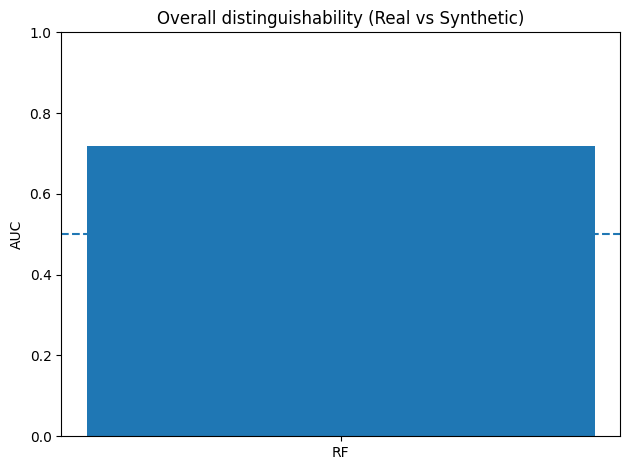

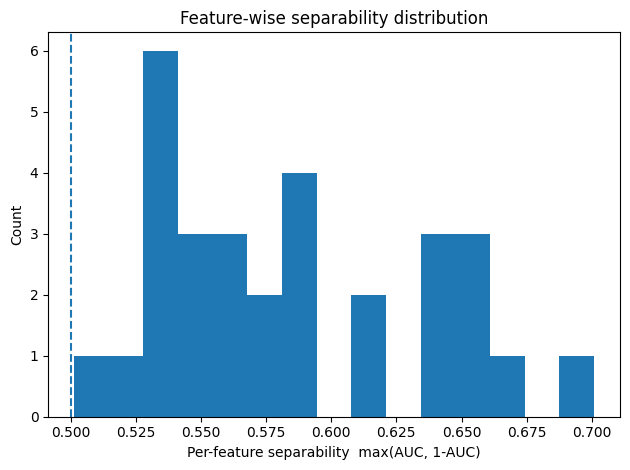

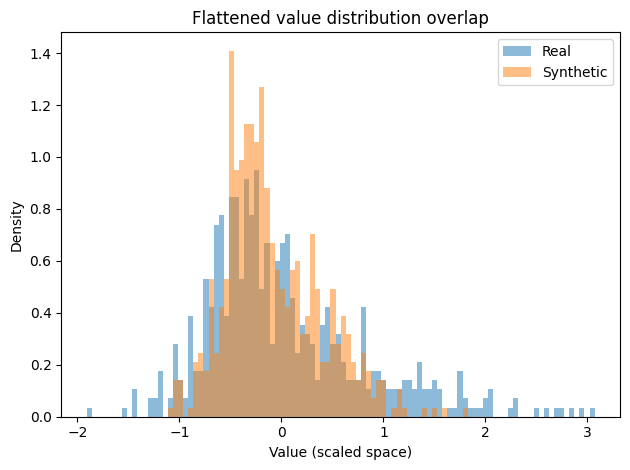

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ---------- helpers ----------
def rf_distinguish_auc_proper(X_real, X_syn, seed=0):
    X_all = np.vstack([X_real, X_syn])
    s_all = np.concatenate([
        np.zeros(len(X_real), dtype=int),
        np.ones(len(X_syn), dtype=int),
    ])

    Xtr, Xte, str_, ste = train_test_split(
        X_all, s_all, test_size=0.2, random_state=seed, stratify=s_all
    )
    rf = RandomForestClassifier(n_estimators=500, random_state=seed)
    rf.fit(Xtr, str_)
    # ensure correct proba column for class 1
    pos_idx = int(np.where(rf.classes_ == 1)[0][0])
    p = rf.predict_proba(Xte)[:, pos_idx]
    return roc_auc_score(ste, p)

def flattened_auc(X_real, X_syn, m=200_000, seed=0):
    rng = np.random.default_rng(seed)
    a = X_real.ravel()
    b = X_syn.ravel()
    m = min(m, len(a), len(b))
    a_s = rng.choice(a, size=m, replace=False)
    b_s = rng.choice(b, size=m, replace=False)
    x = np.concatenate([a_s, b_s])
    y = np.concatenate([np.zeros(m), np.ones(m)])
    auc = roc_auc_score(y, x)
    return auc, max(auc, 1 - auc)

def per_feature_separability(X_real, X_syn):
    p = X_real.shape[1]
    seps = np.zeros(p, dtype=float)
    for j in range(p):
        x = np.concatenate([X_real[:, j], X_syn[:, j]])
        y = np.concatenate([np.zeros(len(X_real)), np.ones(len(X_syn))])
        auc = roc_auc_score(y, x)
        seps[j] = max(auc, 1 - auc)
    return seps

# ---------- compute metrics ----------
auc_rf = rf_distinguish_auc_proper(X_te_s, X_syn, seed=0)
sep_rf = max(auc_rf, 1 - auc_rf)

auc_flat, sep_flat = flattened_auc(X_te_s, X_syn, m=200_000, seed=0)
seps = per_feature_separability(X_te_s, X_syn)

print("RF AUC:", auc_rf, "RF separability:", sep_rf)
print("Flattened AUC:", auc_flat, "Flattened separability:", sep_flat)
print("Top 5 feature separabilities:", np.sort(seps)[-5:][::-1])

# ---------- (A) overall AUC figure ----------
plt.figure()
plt.bar(["RF"], [auc_rf])
plt.axhline(0.5, linestyle="--")
plt.ylim(0.0, 1.0)
plt.ylabel("AUC")
plt.title("Overall distinguishability (Real vs Synthetic)")
plt.tight_layout()
plt.savefig("baseline_overall_auc.png", dpi=300)

# ---------- (B) per-feature AUC distribution ----------
plt.figure()
plt.hist(seps, bins=15)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Per-feature separability  max(AUC, 1-AUC)")
plt.ylabel("Count")
plt.title("Feature-wise separability distribution")
plt.tight_layout()
plt.savefig("baseline_feature_auc_distribution.png", dpi=300)

# ---------- (C) flattened distribution overlap ----------
real_flat = X_te_s.ravel()
syn_flat  = X_syn.ravel()

# use matched bins so overlay is fair
combined = np.concatenate([real_flat, syn_flat])
bins = np.histogram_bin_edges(combined, bins=100)

plt.figure()
plt.hist(real_flat, bins=bins, density=True, alpha=0.5, label="Real")
plt.hist(syn_flat,  bins=bins, density=True, alpha=0.5, label="Synthetic")
plt.title("Flattened value distribution overlap")
plt.xlabel("Value (scaled space)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("baseline_flattened_overlap.png", dpi=300)

plt.show()

[0.50138504 0.52631579 0.52908587 0.52908587 0.53185596 0.53462604
 0.53462604 0.53739612 0.54847645 0.54847645 0.55124654 0.56509695
 0.56509695 0.56509695 0.56786704 0.57894737 0.58171745 0.58448753
 0.58725762 0.5900277  0.60941828 0.61772853 0.63711911 0.6398892
 0.64265928 0.65096953 0.65096953 0.6565097  0.67313019 0.70083102]


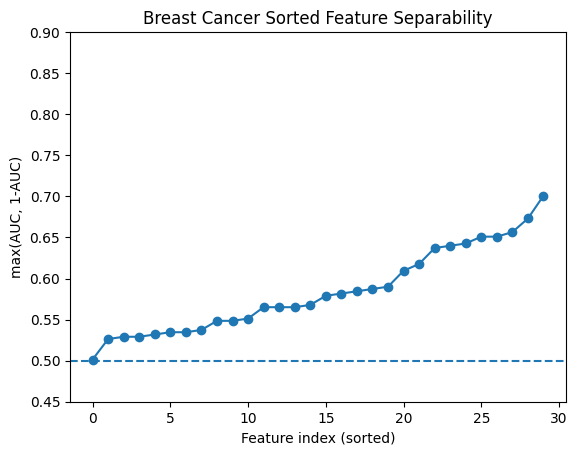

In [13]:
seps_sorted = np.sort(seps)
print(seps_sorted)
plt.figure()
plt.plot(seps_sorted, marker='o')
plt.axhline(0.5, linestyle='--')
plt.ylim(0.45, 0.9)
plt.title("Breast Cancer Sorted Feature Separability")
plt.ylabel("max(AUC, 1-AUC)")
plt.xlabel("Feature index (sorted)")
plt.show()

In [14]:
print("Mean sep:", seps.mean())
print("Max sep:", seps.max())
print("Min sep:", seps.min())

Mean sep: 0.5845798707294552
Max sep: 0.7008310249307479
Min sep: 0.5013850415512465


# Per feature sep

In [15]:
from sklearn.metrics import roc_auc_score
import numpy as np

def per_feature_sep(X_real, X_syn):
    p = X_real.shape[1]
    seps = []
    for j in range(p):
        x = np.concatenate([X_real[:, j], X_syn[:, j]])
        y = np.concatenate([
            np.zeros(len(X_real)),
            np.ones(len(X_syn))
        ])
        auc = roc_auc_score(y, x)
        sep = max(auc, 1 - auc)
        seps.append((j, sep))
    seps.sort(key=lambda t: t[1], reverse=True)
    return seps

seps = per_feature_sep(X_te_s, X_syn)

print("Top 5 features (breast cancer baseline):")
print(seps[:5])

Top 5 features (breast cancer baseline):
[(19, 0.7008310249307479), (18, 0.6731301939058172), (16, 0.6565096952908587), (14, 0.6509695290858726), (15, 0.6509695290858726)]


In [16]:
import matplotlib.pyplot as plt

def violin_top_features(X_real, X_syn, feature_names, top_idx, k=6):
    top_idx = [j for j, _ in top_idx[:k]]

    fig, axes = plt.subplots(k, 1, figsize=(6, 1.8*k))

    if k == 1:
        axes = [axes]

    for ax, j in zip(axes, top_idx):
        real = X_real[:, j]
        syn  = X_syn[:, j]

        parts = ax.violinplot([real, syn],
                              positions=[1, 2],
                              widths=0.8,
                              showmedians=True,
                              showextrema=False)
        med_diff = np.median(real) - np.median(syn)
       
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Real", "Synthetic"])
        # ax.set_title(feature_names[j], fontsize=9)
        ax.set_title(f"{feature_names[j]}  (Δmed = {med_diff:.2f})")
    plt.tight_layout()
    plt.show()

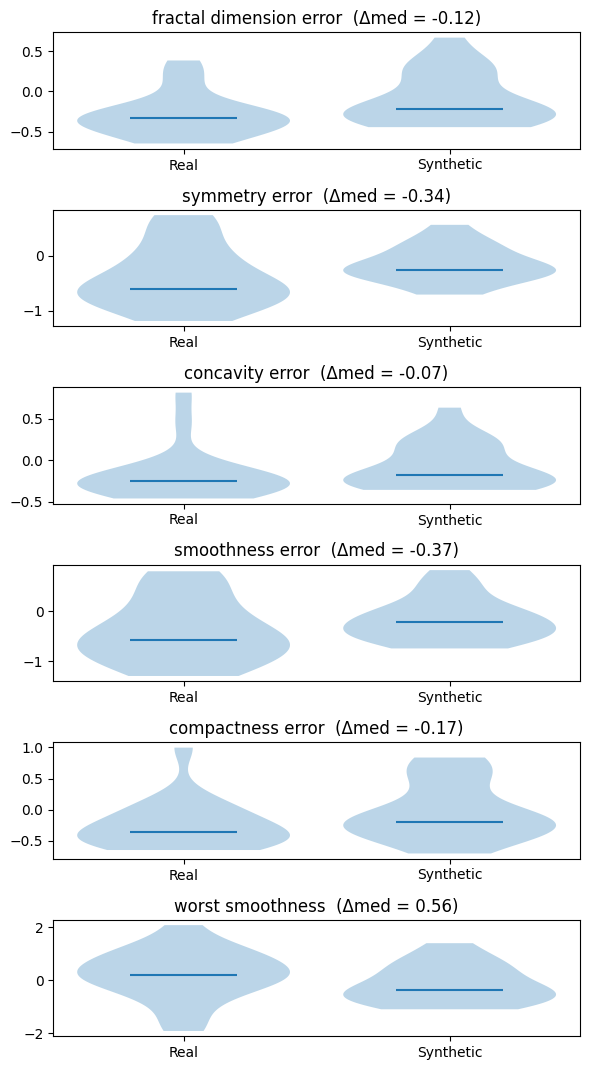

In [17]:
feature_names = data.feature_names  # from sklearn load_breast_cancer

violin_top_features(
    X_real=X_te_s,
    X_syn=X_syn,
    feature_names=feature_names,
    top_idx=seps,
    k=6
)

# Mimicing the conditions of HIV
We want to eliminate the possibility of our high AUC is an artifact of our sampling protocols
- 3/12 hold out.

### Stratify Sampling

In [18]:
import numpy as np

def strat_samp(idx0, idx1, n0, n1, rng):
    a = rng.choice(idx0, size=n0, replace=False)
    b = rng.choice(idx1, size=n1, replace=False)
    return np.concatenate([a, b])

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def one_stochastic_experiment(
    X_real, y_real,
    X_syn,  y_syn,
    holdout0=3, holdout1=12,
    train0=20,  train1=20,
    seed=0
):

    rng = np.random.default_rng(seed)

    real0 = np.where(y_real == 0)[0]
    real1 = np.where(y_real == 1)[0]
    syn0  = np.where(y_syn  == 0)[0]
    syn1  = np.where(y_syn  == 1)[0]

    # holdout indices (stratified, separately in each domain)
    test_real_idx = strat_samp(real0, real1, holdout0, holdout1, rng)
    test_syn_idx  = strat_samp(syn0,  syn1,  holdout0, holdout1, rng)

    # remaining pools for training
    rem_real = np.setdiff1d(np.arange(len(X_real)), test_real_idx)
    rem_syn  = np.setdiff1d(np.arange(len(X_syn)),  test_syn_idx)

    rem_real0 = rem_real[y_real[rem_real] == 0]
    rem_real1 = rem_real[y_real[rem_real] == 1]
    rem_syn0  = rem_syn[y_syn[rem_syn] == 0]
    rem_syn1  = rem_syn[y_syn[rem_syn] == 1]

    train_real_idx = strat_samp(rem_real0, rem_real1, train0, train1, rng)
    train_syn_idx  = strat_samp(rem_syn0,  rem_syn1,  train0, train1, rng)

    # domain classification dataset (s = 0 real, s = 1 synthetic)
    X_train = np.vstack([X_real[train_real_idx], X_syn[train_syn_idx]])
    s_train = np.concatenate([np.zeros(len(train_real_idx), dtype=int),
                              np.ones(len(train_syn_idx), dtype=int)])

    X_test  = np.vstack([X_real[test_real_idx],  X_syn[test_syn_idx]])
    s_test  = np.concatenate([np.zeros(len(test_real_idx), dtype=int),
                              np.ones(len(test_syn_idx), dtype=int)])

    rf = RandomForestClassifier(n_estimators=500, random_state=seed)
    rf.fit(X_train, s_train)
    p = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(s_test, p)

    return auc

In [20]:
n0 = 23
n1 = 68

X_syn0 = sample_scaled(model, n0, 0, device)
X_syn1 = sample_scaled(model, n1, 1, device)

X_syn = np.vstack([X_syn0, X_syn1])
y_syn = np.concatenate([np.zeros(n0), np.ones(n1)])

In [21]:
print("Real class counts:", np.bincount(y))
print(np.bincount(y_syn.astype(int)))

Real class counts: [23 68]
[23 68]


# Trails with holdouts

In [22]:
def run_many_trials(X_real, y_real, X_syn, y_syn, trials=200):
    aucs = []
    for t in range(trials):
        aucs.append(one_stochastic_experiment(
            X_real, y_real, X_syn, y_syn,
            holdout0=3, holdout1=12,
            train0=20,  train1=20,
            seed=t
        ))
    aucs = np.array(aucs)
    return aucs

X_scaled = scaler.transform(X)
aucs = run_many_trials(X_scaled, y, X_syn, y_syn, trials=200)
print("mean AUC:", aucs.mean())
print("std AUC :", aucs.std())
print("min/max :", aucs.min(), aucs.max())

mean AUC: 0.8214222222222222
std AUC : 0.07405671500300995
min/max : 0.5688888888888889 0.9600000000000001


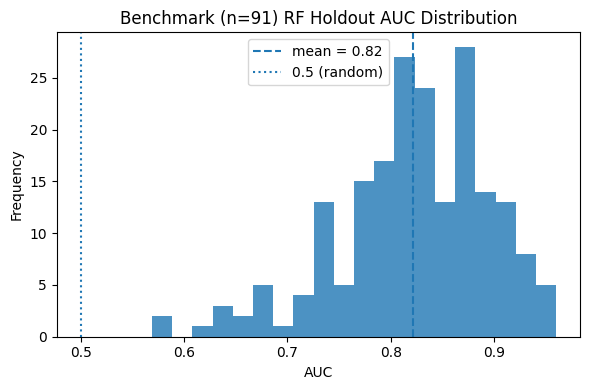

In [23]:
import matplotlib.pyplot as plt
import numpy as np

mean_auc = aucs.mean()

plt.figure(figsize=(6,4))

plt.hist(aucs, bins=20, alpha=0.8)

plt.axvline(mean_auc, linestyle="--", label=f"mean = {mean_auc:.2f}")
plt.axvline(0.5, linestyle=":", label="0.5 (random)")

plt.title("Benchmark (n=91) RF Holdout AUC Distribution")
plt.xlabel("AUC")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()

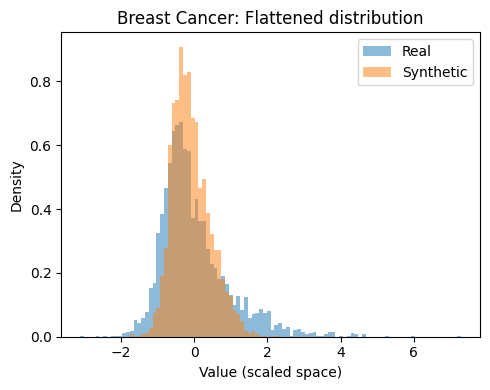

In [40]:
import numpy as np
import matplotlib.pyplot as plt

real_flat = X_scaled.ravel()
syn_flat  = X_syn.ravel()

# use same bins for fair comparison
combined = np.concatenate([real_flat, syn_flat])
bins = np.histogram_bin_edges(combined, bins=100)

plt.figure(figsize=(5,4))

plt.hist(real_flat, bins=bins, density=True, alpha=0.5, label="Real")
plt.hist(syn_flat,  bins=bins, density=True, alpha=0.5, label="Synthetic")

plt.title("Breast Cancer: Flattened distribution")
plt.xlabel("Value (scaled space)")
plt.ylabel("Density")

plt.legend()
plt.tight_layout()
plt.show()

# RF-driven ablation (mirrors HIV protocol)

Same N (91), same class split (23 neg / 68 pos), same RF probe (`n_estimators=500`, 5-fold stratified CV), same RF-importance-driven top-k drop loop as [notebooks/normal/ablation_cvae.ipynb](../notebooks/normal/ablation_cvae.ipynb). Only the feature count differs (30 here vs 63 for HIV), which is inherent to the datasets.

The comparison we're after: does breast cancer's ablation curve drop early as features are removed, or does the AUC stay high until almost everything is gone (the HIV observation)?

In [25]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ---- Wrap real + synthetic as DataFrames with feature names so we can drop by column
feature_names = list(data.feature_names)

real_X = pd.DataFrame(X_scaled, columns=feature_names)   # X_scaled = 91 real, scaled
real_y = np.asarray(y).astype(int)

syn_X  = pd.DataFrame(X_syn,    columns=feature_names)   # X_syn = 91 synthetic (23 neg + 68 pos)
syn_y  = np.asarray(y_syn).astype(int)

# HIV-matched class counts
n_neg = int(min((real_y == 0).sum(), (syn_y == 0).sum()))
n_pos = int(min((real_y == 1).sum(), (syn_y == 1).sum()))
print(f"real: {real_X.shape}  syn: {syn_X.shape}  n_neg={n_neg}  n_pos={n_pos}")

# ---- Stratified RF probe (mirrors HIV's rf_auc_probe_stratified exactly)
rng_ab = np.random.default_rng(42)

def strat_samp_bc(neg_i, pos_i, n_neg, n_pos):
    a = rng_ab.choice(neg_i, size=n_neg, replace=False)
    b = rng_ab.choice(pos_i, size=n_pos, replace=False)
    return np.concatenate([a, b])

def rf_auc_probe_stratified(real_X, real_y, syn_X, syn_y, n_neg, n_pos, seed=42):
    real_y = np.asarray(real_y).astype(int)
    syn_y  = np.asarray(syn_y).astype(int)

    real_neg_i = np.where(real_y == 0)[0]
    real_pos_i = np.where(real_y == 1)[0]
    syn_neg_i  = np.where(syn_y == 0)[0]
    syn_pos_i  = np.where(syn_y == 1)[0]

    real_idx = strat_samp_bc(real_neg_i, real_pos_i, n_neg, n_pos)
    syn_idx  = strat_samp_bc(syn_neg_i,  syn_pos_i,  n_neg, n_pos)

    Xp = pd.concat([real_X.iloc[real_idx], syn_X.iloc[syn_idx]], axis=0).to_numpy()
    sp = np.r_[np.zeros(len(real_idx), dtype=int),
               np.ones(len(syn_idx), dtype=int)]

    rf = RandomForestClassifier(n_estimators=500, random_state=seed, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    aucs = cross_val_score(rf, Xp, sp, cv=cv, scoring="roc_auc")
    return float(aucs.mean()), float(aucs.std()), aucs

real: (91, 30)  syn: (91, 30)  n_neg=23  n_pos=68


In [26]:
def run_ablation(real_X, real_y, syn_X, syn_y, drop_feats, n_neg, n_pos, seed=42, label=""):
    drop_feats = [f for f in drop_feats if f in real_X.columns]
    real_ab = real_X.drop(columns=drop_feats)
    syn_ab  = syn_X.drop(columns=drop_feats)
    m, s, folds = rf_auc_probe_stratified(real_ab, real_y, syn_ab, syn_y, n_neg, n_pos, seed=seed)
    print(f"[{label}] dropped {len(drop_feats)} features | AUC: {m:.3f} +/- {s:.3f}")
    return m, s, folds, drop_feats

# Baseline: nothing dropped
auc0, sd0, folds0 = rf_auc_probe_stratified(real_X, real_y, syn_X, syn_y, n_neg, n_pos)
print(f"[baseline] AUC: {auc0:.3f} +/- {sd0:.3f}  folds={np.round(folds0,3)}")

[baseline] AUC: 0.855 +/- 0.070  folds=[0.858 0.842 0.921 0.924 0.731]


In [27]:
def fit_rf_get_importance(real_X, real_y, syn_X, syn_y, n_neg, n_pos, seed=42):
    real_y = np.asarray(real_y).astype(int)
    syn_y  = np.asarray(syn_y).astype(int)

    real_neg_i = np.where(real_y == 0)[0]
    real_pos_i = np.where(real_y == 1)[0]
    syn_neg_i  = np.where(syn_y == 0)[0]
    syn_pos_i  = np.where(syn_y == 1)[0]

    real_idx = strat_samp_bc(real_neg_i, real_pos_i, n_neg, n_pos)
    syn_idx  = strat_samp_bc(syn_neg_i,  syn_pos_i,  n_neg, n_pos)

    Xp = pd.concat([real_X.iloc[real_idx], syn_X.iloc[syn_idx]], axis=0)
    sp = np.r_[np.zeros(len(real_idx), dtype=int), np.ones(len(syn_idx), dtype=int)]

    rf = RandomForestClassifier(n_estimators=800, random_state=seed, n_jobs=-1)
    rf.fit(Xp, sp)
    return pd.Series(rf.feature_importances_, index=Xp.columns).sort_values(ascending=False)

imp = fit_rf_get_importance(real_X, real_y, syn_X, syn_y, n_neg, n_pos)
imp.head(10)

symmetry error             0.083830
mean radius                0.049676
worst symmetry             0.049145
smoothness error           0.042826
mean area                  0.041879
radius error               0.038988
worst fractal dimension    0.038527
worst smoothness           0.036468
fractal dimension error    0.036305
worst perimeter            0.036293
dtype: float64

In [28]:
auc_l = []
k_list = []
n_features_bc = real_X.shape[1]

for k in range(0, n_features_bc):
    drop_k = imp.head(k).index.tolist()
    m, s, folds, _ = run_ablation(
        real_X, real_y, syn_X, syn_y,
        drop_k, n_neg, n_pos,
        label=f"drop top {k}"
    )
    k_list.append(k)
    auc_l.append(m)

[drop top 0] dropped 0 features | AUC: 0.874 +/- 0.080
[drop top 1] dropped 1 features | AUC: 0.820 +/- 0.091
[drop top 2] dropped 2 features | AUC: 0.855 +/- 0.072
[drop top 3] dropped 3 features | AUC: 0.851 +/- 0.016
[drop top 4] dropped 4 features | AUC: 0.836 +/- 0.077
[drop top 5] dropped 5 features | AUC: 0.832 +/- 0.052
[drop top 6] dropped 6 features | AUC: 0.851 +/- 0.085
[drop top 7] dropped 7 features | AUC: 0.823 +/- 0.083
[drop top 8] dropped 8 features | AUC: 0.833 +/- 0.056
[drop top 9] dropped 9 features | AUC: 0.827 +/- 0.052
[drop top 10] dropped 10 features | AUC: 0.834 +/- 0.055
[drop top 11] dropped 11 features | AUC: 0.832 +/- 0.044
[drop top 12] dropped 12 features | AUC: 0.823 +/- 0.028
[drop top 13] dropped 13 features | AUC: 0.806 +/- 0.034
[drop top 14] dropped 14 features | AUC: 0.802 +/- 0.082
[drop top 15] dropped 15 features | AUC: 0.802 +/- 0.071
[drop top 16] dropped 16 features | AUC: 0.790 +/- 0.099
[drop top 17] dropped 17 features | AUC: 0.800 +/- 

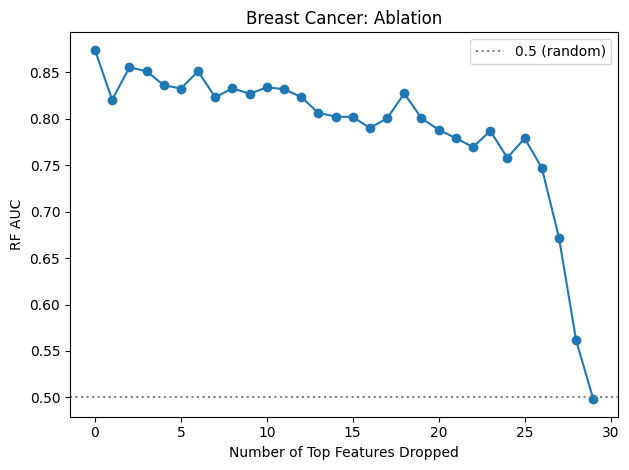

In [29]:
plt.figure()
plt.plot(k_list, auc_l, marker="o")
plt.axhline(0.5, linestyle=":", color="gray", label="0.5 (random)")
plt.xlabel("Number of Top Features Dropped")
plt.ylabel("RF AUC")
plt.title(f"Breast Cancer: Ablation")
plt.legend()
plt.tight_layout()
plt.savefig("baseline_ablation_curve.png", dpi=300)
plt.show()

# Distribution of AUC across methods

For each generator, we run R=50 stratified train/test splits and record the RF probe AUC. The boxplot shows variability and how far each method sits from 0.5 (indistinguishable). Real and synthetic share the same N=91 (23 neg / 68 pos) to mirror the HIV setup.

In [30]:
import sys
sys.path.insert(0, "..")  # so we can import models/

from models.bootstrap import sample_bootstrap
from models.gmm import sample_gmm
from models.iid_columnwise import sample_columnwise

import numpy as np

# Real data: scaled, full subset (91 samples)
X_real_arr = X_scaled
y_real_arr = np.asarray(y).astype(int)

n0_target = int((y_real_arr == 0).sum())  # 23
n1_target = int((y_real_arr == 1).sum())  # 68
print(f"target counts: n0={n0_target}  n1={n1_target}  features={X_real_arr.shape[1]}")


target counts: n0=23  n1=68  features=30


In [31]:
def cvae_sampler(X, y, n0, n1, seed):
    """Re-sample from the trained CVAE with a per-run seed."""
    torch.manual_seed(seed)
    Xs0 = sample_scaled(model, n0, y_label=0, device=device)
    Xs1 = sample_scaled(model, n1, y_label=1, device=device)
    Xs  = np.vstack([Xs0, Xs1])
    ys  = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    return Xs, ys

GENERATORS = {
    "bootstrap":  lambda X, y, n0, n1, seed: sample_bootstrap(X, y, n0, n1, seed=seed),
    "gmm":        lambda X, y, n0, n1, seed: sample_gmm(X, y, n0, n1, seed=seed),
    "columnwise": lambda X, y, n0, n1, seed: sample_columnwise(X, y, n0, n1, seed=seed),
    "cvae":       cvae_sampler,
}


In [32]:
R = 50  # runs per method
results = {}

for name, gen in GENERATORS.items():
    aucs = []
    for r in range(R):
        Xs, ys = gen(X_real_arr, y_real_arr, n0_target, n1_target, seed=r)
        auc = one_stochastic_experiment(
            X_real_arr, y_real_arr,
            Xs, ys,
            holdout0=3, holdout1=12,
            train0=20,  train1=20,
            seed=r,
        )
        aucs.append(auc)
    results[name] = np.array(aucs)
    print(f"{name:10s}  mean={results[name].mean():.3f}  std={results[name].std():.3f}")


bootstrap   mean=0.355  std=0.093
gmm         mean=0.526  std=0.118
columnwise  mean=0.604  std=0.114
cvae        mean=0.814  std=0.082


C:\Users\tonyt\AppData\Local\Temp\ipykernel_24224\1133258975.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)


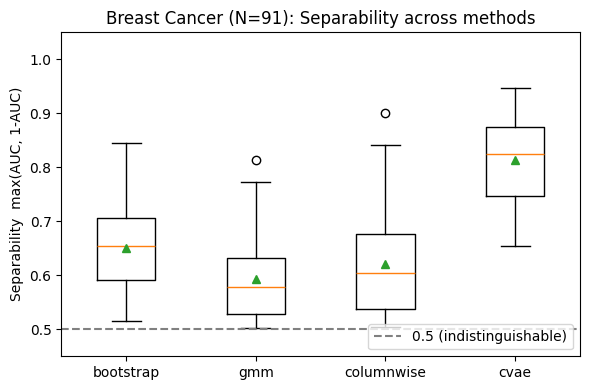

In [33]:
import matplotlib.pyplot as plt

methods = list(results.keys())
data    = [np.maximum(results[m], 1 - results[m]) for m in methods]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(data, labels=methods, showmeans=True)
ax.axhline(0.5, linestyle="--", color="gray", label="0.5 (indistinguishable)")
ax.set_ylim(0.45, 1.05)
ax.set_ylabel("Separability  max(AUC, 1-AUC)")
ax.set_title("Breast Cancer (N=91): Separability across methods")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("bc_method_auc_distribution.png", dpi=300)
plt.show()


# Unrestricted sample size control

The 91-sample subset was chosen to mirror HIV. To rule out sample size as the explanation for the high CVAE distinguishability AUC, we re-run the comparison on the **full** Breast Cancer dataset, train a fresh CVAE on it, and use a standard 80/20 stratified split (no HIV-shaped capping). If CVAE still sits well above 0.5, sample size is not the cause.

In [34]:
from sklearn.datasets import load_breast_cancer

data_full = load_breast_cancer()
X_full = data_full.data
y_full = data_full.target.astype(int)
print("full:", X_full.shape, "class0:", (y_full == 0).sum(), "class1:", (y_full == 1).sum())

scaler_full = StandardScaler().fit(X_full)
X_full_s = scaler_full.transform(X_full)


full: (569, 30) class0: 212 class1: 357


In [35]:
# Train a fresh CVAE on the full dataset
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

X_full_t = torch.tensor(X_full_s, dtype=torch.float32)
y_full_t = torch.tensor(y_full,   dtype=torch.long)

train_loader_full = DataLoader(
    TensorDataset(X_full_t, y_full_t),
    batch_size=cfg.batch_size,
    shuffle=True,
)

model_full = CVAE(x_dim=X_full_s.shape[1], c_dim=2, z_dim=cfg.z_dim, hidden=cfg.hidden).to(device)
opt_full   = torch.optim.Adam(model_full.parameters(), lr=cfg.lr)

for epoch in range(cfg.epochs):
    model_full.train()
    total = 0.0
    for xb, yb in train_loader_full:
        xb = xb.to(device)
        yb = yb.to(device)
        cb = F.one_hot(yb, num_classes=2).float()

        x_hat, mu, logvar = model_full(xb, cb)
        loss = elbo_loss(xb, x_hat, mu, logvar, beta=cfg.beta)

        opt_full.zero_grad()
        loss.backward()
        opt_full.step()
        total += loss.item() * xb.size(0)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | loss={total/len(X_full_t):.4f}")


Epoch  50 | loss=8.0176
Epoch 100 | loss=7.0524
Epoch 150 | loss=6.7978
Epoch 200 | loss=6.5603


In [36]:
def unrestricted_run_auc(X_real, y_real, X_syn, y_syn, seed):
    """Standard 80/20 stratified split on all real+synthetic, RF AUC."""
    X_all = np.vstack([X_real, X_syn])
    s_all = np.r_[np.zeros(len(X_real), dtype=int),
                  np.ones(len(X_syn),  dtype=int)]
    Xtr, Xte, str_, ste = train_test_split(
        X_all, s_all, test_size=0.2, random_state=seed, stratify=s_all
    )
    rf = RandomForestClassifier(n_estimators=500, random_state=seed, n_jobs=-1)
    rf.fit(Xtr, str_)
    p = rf.predict_proba(Xte)[:, 1]
    return roc_auc_score(ste, p)

def cvae_sampler_full(X, y, n0, n1, seed):
    torch.manual_seed(seed)
    Xs0 = sample_scaled(model_full, n0, y_label=0, device=device)
    Xs1 = sample_scaled(model_full, n1, y_label=1, device=device)
    Xs  = np.vstack([Xs0, Xs1])
    ys  = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    return Xs, ys

GENERATORS_FULL = {
    "bootstrap":  lambda X, y, n0, n1, seed: sample_bootstrap(X, y, n0, n1, seed=seed),
    "gmm":        lambda X, y, n0, n1, seed: sample_gmm(X, y, n0, n1, seed=seed),
    "columnwise": lambda X, y, n0, n1, seed: sample_columnwise(X, y, n0, n1, seed=seed),
    "cvae":       cvae_sampler_full,
}

n0_full = int((y_full == 0).sum())
n1_full = int((y_full == 1).sum())
print(f"full N={len(X_full)}  n0={n0_full}  n1={n1_full}")


full N=569  n0=212  n1=357


In [37]:
R = 50
results_full = {}

for name, gen in GENERATORS_FULL.items():
    aucs = []
    for r in range(R):
        Xs, ys = gen(X_full_s, y_full, n0_full, n1_full, seed=r)
        auc = unrestricted_run_auc(X_full_s, y_full, Xs, ys, seed=r)
        aucs.append(auc)
    results_full[name] = np.array(aucs)
    print(f"{name:10s}  mean={results_full[name].mean():.3f}  std={results_full[name].std():.3f}")


bootstrap   mean=0.271  std=0.028
gmm         mean=0.754  std=0.037


KeyboardInterrupt: 

C:\Users\tonyt\AppData\Local\Temp\ipykernel_28968\2973754441.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box_full, labels=methods_full, showmeans=True)


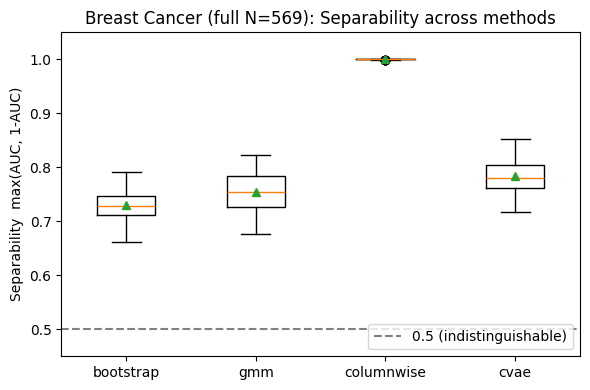

In [ ]:
methods_full = list(results_full.keys())
data_box_full = [np.maximum(results_full[m], 1 - results_full[m]) for m in methods_full]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(data_box_full, labels=methods_full, showmeans=True)
ax.axhline(0.5, linestyle="--", color="gray", label="0.5 (indistinguishable)")
ax.set_ylim(0.45, 1.05)
ax.set_ylabel("Separability  max(AUC, 1-AUC)")
ax.set_title("Breast Cancer (full N=569): Separability across methods")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("bc_full_method_auc_distribution.png", dpi=300)
plt.show()
